# Análise exploratória: Clique Economia (Curitiba)

Dataset do programa Clique Economia, com preços de produtos coletados em supermercados de Curitiba entre 2019 e 2026. O notebook segue este pipeline: estatísticas sobre o dataset completo, amostragem e padronização de tipos, exploração das colunas principais, detecção e tratamento de outliers, cálculo de medidas de posição e dispersão, e visualizações finais sobre preço, rede e correlação entre variáveis.

## 1. Imports e configuração

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theming, visual settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Path constants
DATASET_ZIP = "../dataset/dataset.zip"
IMAGES_DIR = "../docs/images"
CSV_NAME = "final.csv"

# Chunk sampling config
SAMPLE_SIZE = 440_000
RANDOM_STATE = 42

## 2. Preparação do Dataset

### 2.1. Estatísticas sobre Dataset Completo

In [2]:
records, null_counts = 0, 0
data_min, data_max = None, None
year_counts = {}
unique_values = {col: set() for col in ["rede", "descricao", "id_produto", "id_empresa", "codigo_categoria"]}
ranges = {col: {"min": None, "max": None} for col in [
    "id_empresa", "codigo_categoria", "id_produto", "preco_regular",
    "preco_atacado", "preco_atacado_qtd", "preco_promocao", "preco_fidelidade"]}
# media/variancia so para valores reais; identificadores (id_*, codigo_categoria) ficam so com min/max
numeric_stats = {col: {"sum": 0.0, "sq_sum": 0.0, "count": 0} for col in [
    "preco_regular", "preco_atacado", "preco_atacado_qtd", "preco_promocao", "preco_fidelidade"]}

with zipfile.ZipFile(DATASET_ZIP) as z:
  with z.open(CSV_NAME) as f:
      for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
          if records == 0:
              d_types = chunk.dtypes.to_string()
              df_head = chunk.head()

          records += len(chunk)
          null_counts = null_counts + chunk.isnull().sum()

          for col in unique_values:
              unique_values[col].update(chunk[col].dropna().unique())

          datas = pd.to_datetime(chunk["data_pesquisa"], errors="coerce")
          data_min = datas.min() if data_min is None else min(data_min, datas.min())
          data_max = datas.max() if data_max is None else max(data_max, datas.max())
          for year, count in datas.dt.year.value_counts().items():
              year_counts[year] = year_counts.get(year, 0) + count

          for col, acc in ranges.items():
              values = chunk[col].dropna()
              if len(values) > 0:
                  acc["min"] = values.min() if acc["min"] is None else min(acc["min"], values.min())
                  acc["max"] = values.max() if acc["max"] is None else max(acc["max"], values.max())

          for col, acc in numeric_stats.items():
              values = chunk[col].dropna().astype("float64")  # float64 evita overflow de int64 ao elevar ao quadrado
              acc["sum"] += values.sum()
              acc["sq_sum"] += (values ** 2).sum()
              acc["count"] += len(values)

null_pct = (null_counts / records * 100).round(2)
null_table = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_table = null_table[null_table["null_count"] > 0].sort_values("null_count", ascending=False)

print(f"Registros: {records:,}")
print()
print(f"Colunas e Tipos:\n{d_types}")
print()
print(f"Nulos por coluna:\n{null_table}")
print()

df_head

Registros: 4,396,534

Colunas e Tipos:
data_pesquisa            str
id_empresa           float64
rede                     str
codigo_categoria     float64
id_produto             int64
descricao                str
preco_regular        float64
preco_atacado        float64
preco_atacado_qtd      int64
preco_promocao       float64
preco_fidelidade     float64

Nulos por coluna:
                  null_count  null_pct
id_empresa            492077     11.19
codigo_categoria       74907      1.70



,data_pesquisa,id_empresa,rede,codigo_categoria,id_produto,descricao,preco_regular,preco_atacado,preco_atacado_qtd,preco_promocao,preco_fidelidade
0,2026-09-11,2.0,Fuchspan,1.0,7896279600088,Farinha de trigo -coamo -5 kg,15.99,0.0,0,0.0,0.0
1,2026-09-11,115.0,Super muffato,1.0,7896275960896,Leite condensado -frimesa -395 gr,6.49,0.0,0,0.0,0.0
2,2026-09-11,115.0,Super muffato,1.0,7896279600354,Farinha de trigo -coamo -1 kg,3.69,0.0,0,0.0,0.0
3,2026-09-11,115.0,Super muffato,1.0,7896279600088,Farinha de trigo -coamo -5 kg,13.98,0.0,0,0.0,0.0
4,2026-09-11,115.0,Super muffato,5.0,7896275980733,Leite fermentado 06 unidades -frimesa -450 gr,8.69,0.0,0,0.0,0.0


Contagem feita sobre o arquivo inteiro, lendo em blocos (chunks) para não carregar tudo na memória de uma vez.

In [3]:
print(f"data_pesquisa minimo: {data_min.date()}")
print(f"data_pesquisa maximo: {data_max.date()}")
print(f"Intervalo coberto: {(data_max - data_min).days:,} dias")
print()
print("Registros por ano:")
for year in sorted(year_counts):
    print(f"  {year}: {year_counts[year]:,} ({100 * year_counts[year] / records:.2f}%)")

data_pesquisa minimo: 2019-03-01
data_pesquisa maximo: 2026-09-11
Intervalo coberto: 2,751 dias

Registros por ano:
  2019: 25,980 (0.59%)
  2020: 57,213 (1.30%)
  2021: 359,129 (8.17%)
  2022: 355,950 (8.10%)
  2023: 767,498 (17.46%)
  2024: 730,012 (16.60%)
  2025: 1,375,406 (31.28%)
  2026: 725,346 (16.50%)


In [4]:
print(f"id_empresa min: {ranges['id_empresa']['min']}")
print(f"id_empresa max: {ranges['id_empresa']['max']}")
print(f"id_empresa valores unicos: {len(unique_values['id_empresa']):,}")

id_empresa min: 0.0
id_empresa max: 175.0
id_empresa valores unicos: 93


In [5]:
print(f"codigo_categoria min: {ranges['codigo_categoria']['min']}")
print(f"codigo_categoria max: {ranges['codigo_categoria']['max']}")
print(f"codigo_categoria valores unicos: {len(unique_values['codigo_categoria']):,}")

codigo_categoria min: 0.0
codigo_categoria max: 9.0
codigo_categoria valores unicos: 10


In [6]:
print(f"id_produto min: {ranges['id_produto']['min']}")
print(f"id_produto max: {ranges['id_produto']['max']}")
print(f"id_produto valores unicos: {len(unique_values['id_produto']):,}")

id_produto min: 89
id_produto max: 9002490209346
id_produto valores unicos: 2,270


In [7]:
col = "preco_regular"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
# variancia amostral (ddof=1), mesma definicao do .var() usado na secao 5
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_regular min: 0.00
preco_regular max: 549.90
preco_regular media: 10.55
preco_regular variancia: 117.54
preco_regular desvio: 10.84


In [8]:
col = "preco_atacado"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_atacado min: 0.00
preco_atacado max: 95.99
preco_atacado media: 0.06
preco_atacado variancia: 0.72
preco_atacado desvio: 0.85


In [9]:
col = "preco_atacado_qtd"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_atacado_qtd min: 0.00
preco_atacado_qtd max: 0.00
preco_atacado_qtd media: 0.00
preco_atacado_qtd variancia: 0.00
preco_atacado_qtd desvio: 0.00


In [10]:
col = "preco_promocao"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_promocao min: 0.00
preco_promocao max: 109.90
preco_promocao media: 0.12
preco_promocao variancia: 1.84
preco_promocao desvio: 1.36


In [11]:
col = "preco_fidelidade"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_fidelidade min: 0.00
preco_fidelidade max: 62.90
preco_fidelidade media: 0.03
preco_fidelidade variancia: 0.37
preco_fidelidade desvio: 0.60


In [12]:
for col in ["rede", "descricao", "id_produto"]:
    print(f"{col}: {len(unique_values[col]):,} valores unicos")

rede: 100 valores unicos
descricao: 2,771 valores unicos
id_produto: 2,270 valores unicos


### 2.2. Amostragem para análises

In [13]:
samples = []

with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
            # fracao do SAMPLE_SIZE proporcional ao tamanho de cada chunk, mantendo representatividade
            frac = SAMPLE_SIZE / records
            n_sample_chunk = max(1, int(len(chunk) * frac))
            samples.append(chunk.sample(n=n_sample_chunk, random_state=RANDOM_STATE))

df = pd.concat(samples, ignore_index=True)

print(f"Tamanho da amostra: {len(df):,} registros")

Tamanho da amostra: 439,996 registros


Amostra de ~440.000 linhas (~10% do total), sorteada de forma proporcional em cada bloco e com `random_state` fixo (configurado na seção 1), para que o resultado seja reproduzível.

O DataFrame `df` criado nesta célula é a amostra de referência usada em todas as seções seguintes do notebook.

### 2.3. Padronização

In [14]:
df["data_pesquisa"] = pd.to_datetime(df["data_pesquisa"], errors="coerce").dt.normalize()

for column in ["id_empresa", "codigo_categoria", "id_produto", "preco_atacado_qtd"]:
    df[column] = df[column].astype("Int64")

print(df.dtypes.to_string())
print()
df.head()

data_pesquisa        datetime64[us]
id_empresa                    Int64
rede                            str
codigo_categoria              Int64
id_produto                    Int64
descricao                       str
preco_regular               float64
preco_atacado               float64
preco_atacado_qtd             Int64
preco_promocao              float64
preco_fidelidade            float64



,data_pesquisa,id_empresa,rede,codigo_categoria,id_produto,descricao,preco_regular,preco_atacado,preco_atacado_qtd,preco_promocao,preco_fidelidade
0,2026-08-07,115,Super muffato,6,7891024035047,Sabonete antibacteriano -protex -85 gr,3.74,0.0,0,0.0,0.0
1,2026-07-06,75,Jacomar,1,7898342050257,Sardinha molho de tomate -nautique -125 gr,5.29,0.0,0,0.0,0.0
2,2026-07-27,<NA>,Max atacadista,1,7897001010304,Oleo de canola -suavit -900 ml,11.19,0.0,0,0.0,0.0
3,2026-07-29,104,Festval,1,7898171400049,Feijao preto -pe vermelho -1 kg,5.98,0.0,0,0.0,0.0
4,2026-04-14,80,Super boni,<NA>,7896181710240,Mandolate -dacolonia -130 gr,7.49,0.0,0,0.0,0.0


**Observação sobre os tipos:**
- `data_pesquisa`: convertida para `datetime`, precisão de dia.
- `id_empresa`, `codigo_categoria` são identificadores numéricos que possuem nulos, por isso `Int64`.
- `preco_atacado_qtd` e `id_produto` são contador e identificador não nulos, convertidos para `Int64` apenas por padronização

## 3. Exploração da amostra

### 3.1. Produtos e Descrição

In [15]:
descriptions_by_product = df.groupby("id_produto")["descricao"].nunique()

print(f"Produtos distintos: {len(descriptions_by_product):,}")
print()

description_count_distribution = descriptions_by_product.value_counts().sort_index()
description_distribution = pd.DataFrame({
    "qtd_descricoes": description_count_distribution.index,
    "qtd_produtos": description_count_distribution.values
})
description_distribution["pct"] = (description_distribution["qtd_produtos"] / len(descriptions_by_product) * 100).round(2)

print(description_distribution.to_string(index=False))
print()

for count in description_distribution["qtd_descricoes"]:
    if count <= 1:
        continue
        
    print(f"Exemplos com {count} descrições:")
    
    group_ids = descriptions_by_product[descriptions_by_product == count].index[:2]
    for id_produto in group_ids:
        descriptions = df[df["id_produto"] == id_produto]["descricao"].unique()
        print(f"\n  id_produto {id_produto}:")
        for description in descriptions:
            print(f"    - {description!r}")
    print()

Produtos distintos: 2,089

 qtd_descricoes  qtd_produtos   pct
              1          1732 82.91
              2           288 13.79
              3            62  2.97
              4             6  0.29
              5             1  0.05

Exemplos com 2 descrições:

  id_produto 546:
    - 'Linguica de carne suina congelada -juliatto -1 kg'
    - 'Linguiaa de carne suana congelada -juliatto -1 kg'

  id_produto 1130:
    - 'Bisteca suana fatiada   -juliatto -1 kg'
    - 'Bisteca suina fatiada   -juliatto -1 kg'

Exemplos com 3 descrições:

  id_produto 111111:
    - 'Acucar cristal  -( + ) barato -5 kg'
    - 'Acucar cristal -( + ) barato -5 kg'
    - 'Aaacar cristal  -( + ) barato -5 kg'

  id_produto 111112:
    - 'Acucar refinado -( + ) barato -1 kg'
    - 'Acucar refinado  -( + ) barato -1 kg'
    - 'Aaacar refinado  -( + ) barato -1 kg'

Exemplos com 4 descrições:

  id_produto 111123:
    - 'Azeitona em conserva sache -( + ) barato -120 gr'
    - 'Azeitonas em conserva sache

`id_produto` é consistentemente o **mesmo** produto, mesmo que a descrição tenha variações de escrita.

### 3.2. Categoria e Produto

In [16]:
categories_by_product = df.groupby("id_produto")["codigo_categoria"].nunique()

print(f"Produtos distintos: {len(categories_by_product):,}")
print()

category_count_distribution = categories_by_product.value_counts().sort_index()
category_distribution = pd.DataFrame({
  "qtd_categorias": category_count_distribution.index,
  "qtd_produtos": category_count_distribution.values
})
category_distribution["pct"] = (category_distribution["qtd_produtos"] / len(categories_by_product) * 100).round(2)

category_distribution

Produtos distintos: 2,089



,qtd_categorias,qtd_produtos,pct
0,0,47,2.25
1,1,2034,97.37
2,2,8,0.38


O código de categoria é estável por produto, mas não há campo que diga o que cada código significa. Seria possível inferir a categoria pelos produtos de cada código, com pouca confiabilidade. Por isso, o campo tem utilidade limitada na análise.

### 3.3. Rede e id_empresa

In [17]:
networks_by_company = df.groupby("id_empresa")["rede"].nunique()

print(f"Empresas distintas: {len(networks_by_company):,}")
print()

network_count_distribution = networks_by_company.value_counts().sort_index()
network_distribution = pd.DataFrame({
  "qtd_redes": network_count_distribution.index,
  "qtd_empresas": network_count_distribution.values
})
network_distribution["pct"] = (network_distribution["qtd_empresas"] / len(networks_by_company) * 100).round(2)

print(network_distribution.to_string(index=False))
print()

for count in network_distribution["qtd_redes"]:
  if count <= 1:
      continue
  group_ids = networks_by_company[networks_by_company == count].index[:2]
  print(f"Exemplos com {count} redes:")
  for id_empresa in group_ids:
      networks = df[df["id_empresa"] == id_empresa]["rede"].unique()
      print(f"\n  id_empresa {id_empresa}:")
      for network in networks:
          print(f"    - {network!r}")
  print()

Empresas distintas: 92

 qtd_redes  qtd_empresas   pct
         1            60 65.22
         2            28 30.43
         3             4  4.35

Exemplos com 2 redes:

  id_empresa 6:
    - 'Condor'
    - 'Stall'

  id_empresa 22:
    - 'Condor'
    - 'Rio verde'

Exemplos com 3 redes:

  id_empresa 29:
    - 'Atacadao'
    - 'Big'
    - 'Triunfo supermercados'

  id_empresa 30:
    - 'Araucaria'
    - 'Arauca!ria'
    - 'Italo'



`id_empresa` não é um identificador único em todo o dataset, apenas dentro da própria rede: o mesmo número é reaproveitado por redes diferentes. Para identificar uma filial de forma inequívoca, é necessário usar a combinação `(id_empresa, rede)`.

### 3.4. Preços não regulares

In [18]:
special_prices = {
  "preco_atacado": "atacado",
  "preco_promocao": "promoção",
  "preco_fidelidade": "fidelidade"
}
      
for column, label in special_prices.items():
  summary = df.groupby("rede").agg(
      total_registros=(column, "size"),
      com_preco_especial=(column, lambda x: (x > 0).sum())
  )
  summary["pct_com_preco"] = (summary["com_preco_especial"] / summary["total_registros"] * 100).round(2)
  summary = summary[summary["com_preco_especial"] > 0].sort_values("pct_com_preco", ascending=False)

  print(f"Redes com {label} (ordenado por % de produtos com esse preço):")
  print(summary.head(10).to_string())
  print()

Redes com atacado (ordenado por % de produtos com esse preço):
                  total_registros  com_preco_especial  pct_com_preco
rede                                                                
Jumbo atacadista              384                 125          32.55
Atacadapso                   1340                 126           9.40
Armazem da maria             5208                 463           8.89
Super dia                    1820                 156           8.57
Atacadao                    26615                2261           8.50
Assaa                         893                  50           5.60
Big                          9237                 451           4.88
Gigante                       504                  18           3.57
Assai                       14969                 267           1.78
Carrefour                   16813                 133           0.79

Redes com promoção (ordenado por % de produtos com esse preço):
                     total_registros  com_pr

Apenas uma pequena porcentagem de produtos e redes pratica preços promocionais, de atacado ou de fidelidade. Mesmo assim, esses preços não podem ser descartados: parte dos registros tem `preco_promocao` sem `preco_regular` (seção 3.5).

As duas últimas explorações também mostram inconsistência no nome das redes. Sem um identificador único de rede, normalizar esse campo por regra automática pode juntar redes diferentes ou separar a mesma rede.

### 3.5. Nulos/Zero

In [19]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

null_table = pd.DataFrame({"null_count": nulls, "null_pct": null_pct})
null_table = null_table[null_table["null_count"] > 0].sort_values("null_count", ascending=False)
null_table

,null_count,null_pct
id_empresa,49169,11.17
codigo_categoria,7476,1.70


Porcentagem de nulos na amostra é muito parecida com o dataset inteiro: no dataset completo (seção 2.1), `id_empresa` tinha 492.077 nulos (11,19%) e `codigo_categoria` tinha 74.907 nulos (1,70%); na amostra, os percentuais ficam em 11,17% e 1,70%, respectivamente. A amostragem preservou a proporção original de nulos.

- `id_empresa`: identificador de filial (seção 3.3). Os nulos foram mantidos, já que nenhuma análise depende de filial.
- `codigo_categoria`: proporção baixa de nulos; conforme visto anteriormente tem valor limitado para análise.
- Nenhuma outra coluna tem valores nulos.

In [20]:
price_columns = ["preco_regular", "preco_atacado", "preco_promocao", "preco_fidelidade"]
has_price = df[price_columns].gt(0)
pattern_counts = has_price.value_counts()

pattern_table = pattern_counts.reset_index(name="qtd_registros")
pattern_table["pct"] = (pattern_table["qtd_registros"] / len(df) * 100).round(2)

pattern_table

,preco_regular,preco_atacado,preco_promocao,preco_fidelidade,qtd_registros,pct
0,True,False,False,False,426899,97.02
1,False,False,True,False,6791,1.54
2,True,True,False,False,4037,0.92
3,True,False,False,True,1161,0.26
4,True,False,True,False,759,0.17
5,True,False,True,True,186,0.04
6,True,True,False,True,69,0.02
7,False,False,True,True,63,0.01
8,False,False,False,True,11,0.00
9,True,True,True,False,6,0.00


Não há consistência total de preenchimento de preços: a grande maioria tem `preco_regular`, porém há uma parcela não desprezível em que há `preco_promocao`, mas não `preco_regular`. Precisamos criar um campo normalizado com um preço "base" para ser utilizado nas análises.

No caso de mais de um preço ser preenchido, `preco_promocao` tem prioridade, por ser o valor que a população geral paga. Em todos os outros cenários, `preco_regular` tem prioridade, já que nem todas as redes praticam preços de atacado ou com fidelidade e não podemos assumir que todas as compras sejam feitas nessa modalidade.

In [21]:
no_price_mask = (df["preco_regular"] <= 0) & (df["preco_atacado"] <= 0) & (df["preco_promocao"] <= 0) & (df["preco_fidelidade"] <= 0)
print(f"Registros sem nenhum preço preenchido: {no_price_mask.sum():,}")

price_priority = ["preco_promocao", "preco_regular", "preco_fidelidade", "preco_atacado"]
# bfill pega o primeiro preco nao-zero na ordem de prioridade definida acima
prices_as_na = df[price_priority].replace(0, np.nan)
df["preco_efetivo"] = prices_as_na.bfill(axis=1).iloc[:, 0].astype("float64")

Registros sem nenhum preço preenchido: 6


Os registros sem nenhum preço ficam com `preco_efetivo` vazio. Nesta exploração eles foram mantidos; na análise da cesta básica (seção 7), precisam ser removidos.

### 3.6. Itens da cesta básica e tamanho da embalagem

In [22]:
# tamanho = numero seguido de unidade, ou unidade sozinha para itens vendidos a granel (ex.: "- kg", "- un.")
size_info_pattern = r"-\s*(?:\d+(?:[.,]\d+)?\s*[a-z]|(?:kg|un)\b)"

desc_lower = df["descricao"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
basic_mask = desc_lower.str.contains(r"arroz|feijao|acucar|oleo", regex=True, na=False)
basic_desc = desc_lower[basic_mask]

basic_types = pd.DataFrame({
    # tipo = texto antes do primeiro hifen, sem marcadores como "( + ) barato"
    "tipo": basic_desc.str.replace(r"\(.*?\)", "", regex=True).str.split("-").str[0].str.strip(),
    "comeca_com_item": basic_desc.str.match(r"(?:arroz|feijao|acucar|oleo)\b"),
    "tem_tamanho": basic_desc.str.contains(size_info_pattern, regex=True),
})
type_summary = basic_types.groupby(["comeca_com_item", "tipo"]).agg(
    registros=("tem_tamanho", "size"), pct_com_tamanho=("tem_tamanho", lambda s: round(100 * s.mean(), 1)))

print(f"Registros com arroz, feijão, açúcar ou óleo na descrição: {len(basic_types):,}")
print()
print("Descrições que começam pelo item (tipos do item):")
type_summary.loc[True].sort_values(["tipo", "registros"], ascending=[True, False])

Registros com arroz, feijão, açúcar ou óleo na descrição: 46,865

Descrições que começam pelo item (tipos do item):


,registros,pct_com_tamanho
tipo,,
acucar cristal,2558,99.0
acucar cristal extra fino,25,0.0
acucar demerara,698,93.1
acucar mascavo,702,99.9
acucar mascavo barato,307,0.0
acucar refinado,4698,99.9
acucar refinado barato,929,0.0
acucar refinado .,39,100.0
acucar refinado extra fino,380,100.0


In [23]:
print("Descrições que só contêm a palavra (outros produtos):")
type_summary.loc[False].sort_values("registros", ascending=False)

Descrições que só contêm a palavra (outros produtos):


,registros,pct_com_tamanho
tipo,,
farinha de arroz,983,84.4
massa alimenticia de arroz parafuso zero gluten,647,100.0
sardinha em oleo comestivel,587,95.1
refrigerante,544,100.0
atum solido ao oleo,531,100.0
achocolatado em po zero acucar,467,94.6
massa alimenticia de arroz pena isenta de gluten,362,0.0
massa alimenticia de arroz parafuso,328,0.0
massa alimenticia de arroz pena zero gluten,286,100.0


Os itens essenciais da proposta (arroz, feijão, açúcar e óleo) aparecem em descrições muito diferentes. As que só contêm a palavra são outros produtos, como massa de arroz, sardinha em óleo e refrigerante "sem açúcar", e precisam ficar de fora. As que começam pelo item misturam tipos de preço diferente, como arroz polido e integral ou óleo de soja e canola. O mesmo tipo aparece ora com tamanho de embalagem, ora sem, e a falta de tamanho se concentra antes de 2023 (seção 3.7).

Na análise da cesta básica (seção 7), os itens precisam ser selecionados por regras que exijam a descrição começando pelo item e por tipo, e não pela simples presença da palavra.

### 3.7. Itens sem tamanho de embalagem

In [24]:
has_size = df["descricao"].str.lower().str.contains(size_info_pattern, regex=True, na=False)

size_by_year = has_size.groupby(df["data_pesquisa"].dt.year).agg(
    registros="size", com_tamanho="sum", pct=lambda s: round(100 * s.mean(), 2))
print(size_by_year.to_string())
print()
print("Exemplos sem tamanho (até 2022):")
print(df.loc[~has_size & (df["data_pesquisa"].dt.year <= 2022), "descricao"].value_counts().head(5).to_string())
print()
print("Exemplos com tamanho (a partir de 2024):")
print(df.loc[has_size & (df["data_pesquisa"].dt.year >= 2024), "descricao"].value_counts().head(5).to_string())

               registros  com_tamanho     pct
data_pesquisa                                
2019                2584           83    3.21
2020                5731          202    3.52
2021               35913         1341    3.73
2022               35621         1658    4.65
2023               76858        67450   87.76
2024               73014        73014  100.00
2025              137581       137581  100.00
2026               72694        72694  100.00

Exemplos sem tamanho (até 2022):
descricao
Arroz parboilizado  ( + ) barato          865
Arroz polido ( + ) barato                 853
Acucar refinado ( + ) barato              827
Farinha de trigo especial ( + ) barato    807
Arroz parboilizado                        761

Exemplos com tamanho (a partir de 2024):
descricao
Manteiga primeira qualidade com sal  -tirol -200 gr    814
Cebola -1 kg                                           762
Laranja pera -1 kg                                     756
Maracuja -1 kg                       

In [25]:
# cobertura de tamanho mes a mes em 2023, ano da troca de codigos
in_2023 = df["data_pesquisa"].dt.year == 2023
size_by_month = has_size[in_2023].groupby(df.loc[in_2023, "data_pesquisa"].dt.to_period("M")).agg(
    registros="size", com_tamanho="sum", pct=lambda s: round(100 * s.mean(), 2))
print(size_by_month.to_string())
print()
print(f"Primeiro mês de 2023 com 100% dos registros com tamanho: {size_by_month[size_by_month['pct'] == 100].index.min()}")

               registros  com_tamanho     pct
data_pesquisa                                
2023-01             3479          152    4.37
2023-02             3394          133    3.92
2023-03             3442          627   18.22
2023-04             5409         5409  100.00
2023-05             9216         9216  100.00
2023-06            11584        11579   99.96
2023-07             7610         7610  100.00
2023-08             7389         7389  100.00
2023-09             6350         6350  100.00
2023-10             7676         7676  100.00
2023-11             5803         5803  100.00
2023-12             5506         5506  100.00

Primeiro mês de 2023 com 100% dos registros com tamanho: 2023-04


A descrição costuma trazer o tamanho da embalagem no fim (ex.: "-5 kg", "-900 ml", "-1 un"). Sem ele, não há como saber se o preço é de 1 kg ou de 5 kg, e preços do mesmo item deixam de ser comparáveis. A tabela acima mostra a proporção de registros com tamanho por ano, para todos os produtos da amostra.

Até 2022, a pesquisa registrava produtos genéricos, sem marca nem embalagem (ex.: "Arroz polido"). Em março de 2023, os códigos de produto foram substituídos por códigos específicos, com marca e tamanho, e nenhum código antigo continuou em uso. Na amostra, a troca aparece em março (18% dos registros com tamanho), e a partir de abril de 2023 praticamente todos os registros trazem tamanho; a única exceção são 5 registros de junho. Por isso, na análise da cesta básica (seção 7), os registros sem tamanho precisam ser removidos, e a comparação de preços fica restrita a 2023 em diante. Nesta amostra, eles somam 85.973 registros; dos anos anteriores a 2023, só 3.283 trazem tamanho (ex.: papel higiênico, saco de lixo). Nesta etapa exploratória, os registros foram mantidos.

## 4. Detecção de outliers

### 4.1. Preços altos (IQR)

In [26]:
q1 = df["preco_efetivo"].quantile(0.25)
q3 = df["preco_efetivo"].quantile(0.75)
iqr = q3 - q1
# limites classicos de outlier por IQR (1.5x alem do Q1/Q3)
floor = q1 - 1.5 * iqr
ceiling = q3 + 1.5 * iqr

outliers = df[(df["preco_efetivo"] < floor) | (df["preco_efetivo"] > ceiling)]
print(f"Limite Inferior: {floor:.2f}")
print(f"Limite Superior: {ceiling:.2f}")
print(f"Outliers: {len(outliers):,} ({100*len(outliers)/len(df):.2f}% da amostra)")
print()

print("Top 10 preços")
df.nlargest(10, "preco_efetivo")[["descricao", "rede", "preco_efetivo"]]

Limite Inferior: -8.75
Limite Superior: 26.02
Outliers: 33,922 (7.71% da amostra)

Top 10 preços


,descricao,rede,preco_efetivo
435312,Carne bovina patinho s- osso ( pedaco ),Michel,439.99
350753,Carne bovina posta vermelha s- osso (pedaco),Rio verde,429.00
409448,Cerveja antartica lata,Big,212.19
370316,Carne bovina file mignon s- osso,Angeloni,155.90
31150,Carne bovina file mignon s/ osso -( + ) barato...,Festval,149.98
94897,Carne bovina file mignon s/ osso -( + ) barato...,Angeloni,149.90
76606,Carne bovina file mignon s/ osso -( + ) barato...,Festval,139.98
389877,Carne bovina file mignon s- osso,Angeloni,139.90
357961,Carne bovina file mignon s- osso,G,139.75
361094,Carne bovina file mignon s- osso,Big,135.00


Os outliers de preço alto (limite superior do IQR: 26,02 reais, 7,71% da amostra) são majoritariamente carnes nobres e itens de maior valor agregado, que são valores legítimos e não erros. Decisão: manter esses registros, mas segmentar por categoria quando a comparação de preços exigir homogeneidade (não comparar filé mignon com fermento na mesma distribuição).

### 4.2. Preços muito baixos

In [27]:
thresholds = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00, 1.50, 2.00]
threshold_table = pd.DataFrame({
    "limiar": thresholds,
    "qtd_registros": [(df["preco_efetivo"] <= t).sum() for t in thresholds],
})
threshold_table["pct"] = (threshold_table["qtd_registros"] / len(df) * 100).round(4)

print("Itens com preços baixos")
threshold_table

Itens com preços baixos


,limiar,qtd_registros,pct
0,0.01,3,0.0007
1,0.05,14,0.0032
2,0.10,16,0.0036
3,0.20,17,0.0039
4,0.30,25,0.0057
5,0.50,47,0.0107
6,0.70,146,0.0332
7,1.00,1695,0.3852
8,1.50,6640,1.5091
9,2.00,19715,4.4807


In [28]:
low_price_mask = df["preco_efetivo"] < 0.50
print(f"Registros com preco_efetivo < 0.50: {low_price_mask.sum()} ({100*low_price_mask.sum()/len(df):.4f}%)")
df[low_price_mask][["descricao", "rede", "preco_efetivo"]].sort_values("preco_efetivo")

Registros com preco_efetivo < 0.50: 47 (0.0107%)


,descricao,rede,preco_efetivo
402819,Achocolatado em po,Jacomar,0.01
375376,Gengibre,Supermercado italia,0.01
356286,Acucar mascavo,Condor,0.01
359912,Fermento quimico,Supermercado mariano,0.02
361633,Papel higienico 08 rolos 60m,Carrefour,0.02
393687,Sabao liquido lava roupas,Italo,0.02
353833,Linguica calabresa fininha,Supermercado mariano,0.02
396551,Frango congelado - asa,Supermercado italia,0.02
420296,Hamburguer bovino,Colatusso,0.02
421037,Saco plastico p- lixo - 30 l,Condor,0.02


Pelas descrições listadas acima, itens com valor menor que 0,30 são provavelmente falha de captura de dados (açúcar, carne e papel higiênico a poucos centavos). Entre 0,30 e 0,50 já aparecem preços plausíveis para itens pequenos, como cheiro-verde e esponja. O limite inferior foi definido em 0,30, e os itens abaixo dele foram removidos.

In [29]:
low_price_cut = df["preco_efetivo"] < 0.30
df = df[~low_price_cut].reset_index(drop=True)
print(f"Registros restantes apos remocao: {len(df):,}")

Registros restantes apos remocao: 439,971


## 5. Medidas de posição e dispersão

In [30]:
summary_columns = price_columns + ["preco_efetivo"]

price_summary = df[summary_columns].describe().T
price_summary["variancia"] = df[summary_columns].var()
price_summary["coef variancia"] = (df[summary_columns].std() / df[summary_columns].mean()).round(3)
price_summary["moda"] = df[summary_columns].mode().iloc[0]
price_summary["amplitude"] = df[summary_columns].max() - df[summary_columns].min()

price_summary

,count,mean,std,min,25%,50%,75%,max,variancia,coef variancia,moda,amplitude
preco_regular,439971.0,10.538978,10.845609,0.00,4.18,6.98,12.90,439.99,117.627244,1.029,4.99,439.99
preco_atacado,439971.0,0.062236,0.842284,0.00,0.00,0.00,0.00,55.90,0.709442,13.534,0.00,55.90
preco_promocao,439971.0,0.122449,1.358032,0.00,0.00,0.00,0.00,89.99,1.844251,11.091,0.00,89.99
preco_fidelidade,439971.0,0.027832,0.636129,0.00,0.00,0.00,0.00,45.90,0.404661,22.856,0.00,45.90
preco_efetivo,439965.0,10.637932,10.809622,0.32,4.29,6.98,12.98,439.99,116.847927,1.016,4.99,439.67


- `preco_regular` é a única coluna preenchida com valor relevante em praticamente todas as linhas. As demais (`preco_atacado`, `preco_promocao`, `preco_fidelidade`) têm mediana e moda iguais a zero, pois como estabelecemos anteriormente, representam condições especiais de venda que não se aplicam à maioria dos produtos e redes.
- O coeficiente de variação de `preco_regular` (1,03) indica dispersão relativa alta, com desvio padrão maior que a média, coerente com a diversidade de categorias (de itens baratos como fermento até itens caros como carnes nobres).
- `preco_efetivo` (seção 3.5) tem média e mediana próximas das de `preco_regular`, já que a maioria dos registros usa o preço regular como preço efetivo. A média um pouco maior e o desvio um pouco menor vêm principalmente da substituição dos zeros de `preco_regular` pelos outros preços disponíveis; a troca do preço regular pela promoção tem efeito pequeno.

In [31]:
quantiles = df["preco_efetivo"].quantile([0.25, 0.5, 0.75])
decis = df["preco_efetivo"].quantile([i / 10 for i in range(1, 10)])
key_percentiles = df["preco_efetivo"].quantile([0.01, 0.05, 0.95, 0.99])

print(f"preco_efetivo quartis:")
print(quantiles.to_string())
print(f"\npreco_efetivo decis:")
print(decis.to_string())
print(f"\npreco_efetivo percentiles:")
print(key_percentiles.to_string())
print()

preco_efetivo quartis:
0.25     4.29
0.50     6.98
0.75    12.98

preco_efetivo decis:
0.1     2.98
0.2     3.98
0.3     4.85
0.4     5.79
0.5     6.98
0.6     8.39
0.7    10.98
0.8    14.99
0.9    22.99

preco_efetivo percentiles:
0.01     1.39
0.05     2.25
0.95    31.98
0.99    54.90



- A mediana (6,98 reais) fica abaixo da média (10,64 reais), sinal de assimetria à direita: poucos itens caros puxam a média para cima.
- Metade dos registros está entre 4,29 e 12,98 reais (intervalo interquartil de 8,69 reais).
- Entre os decis de 10% e 90%, o preço vai de 2,98 a 22,99 reais, quase 8 vezes. A base mistura itens baratos de mercearia com produtos de maior valor, como carnes e bebidas.
- A cauda superior cresce rápido: do percentil 95% (31,98 reais) para o 99% (54,90 reais) o preço sobe 72%, enquanto do decil 80% para o 90% sobe 53%.

## 6. Exploração Visual

### 6.1. Distribuição dos dados

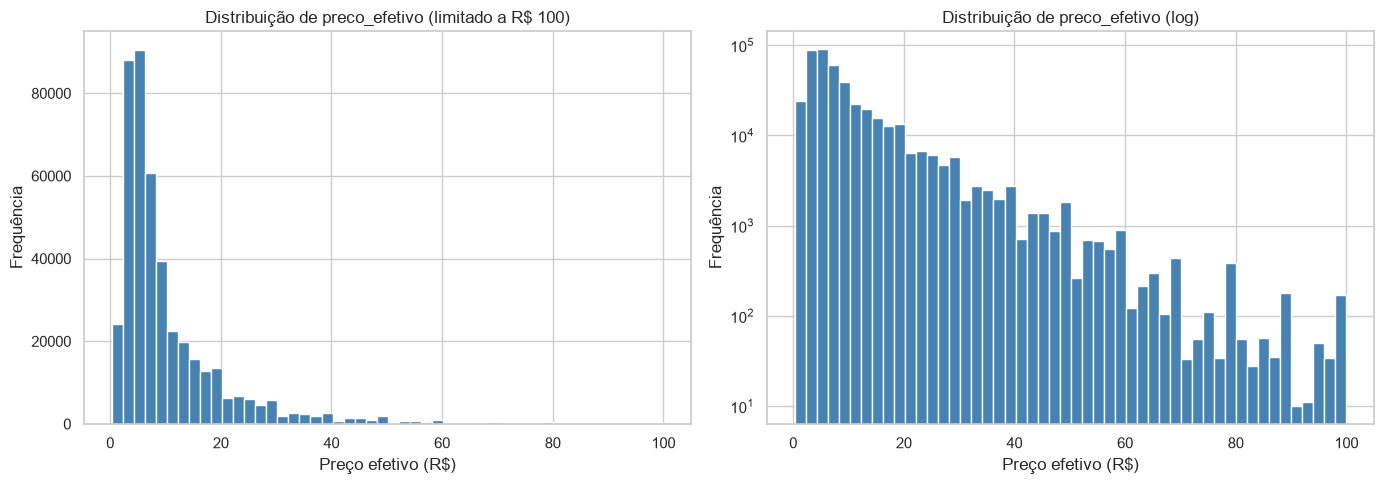

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["preco_efetivo"].clip(upper=100), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição de preco_efetivo (limitado a R$ 100)")
axes[0].set_xlabel("Preço efetivo (R$)")
axes[0].set_ylabel("Frequência")

axes[1].hist(df["preco_efetivo"].clip(upper=100), bins=50, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Distribuição de preco_efetivo (log)")
axes[1].set_xlabel("Preço efetivo (R$)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/distribuicao_preco_efetivo.png", dpi=150)
plt.show()

Distribuição fortemente assimétrica à direita: a maioria dos itens está concentrada em valores baixos, com uma cauda longa de preços altos (visível na comparação entre a escala linear e a escala log).

### 6.2.  Redes com mais registros na amostra

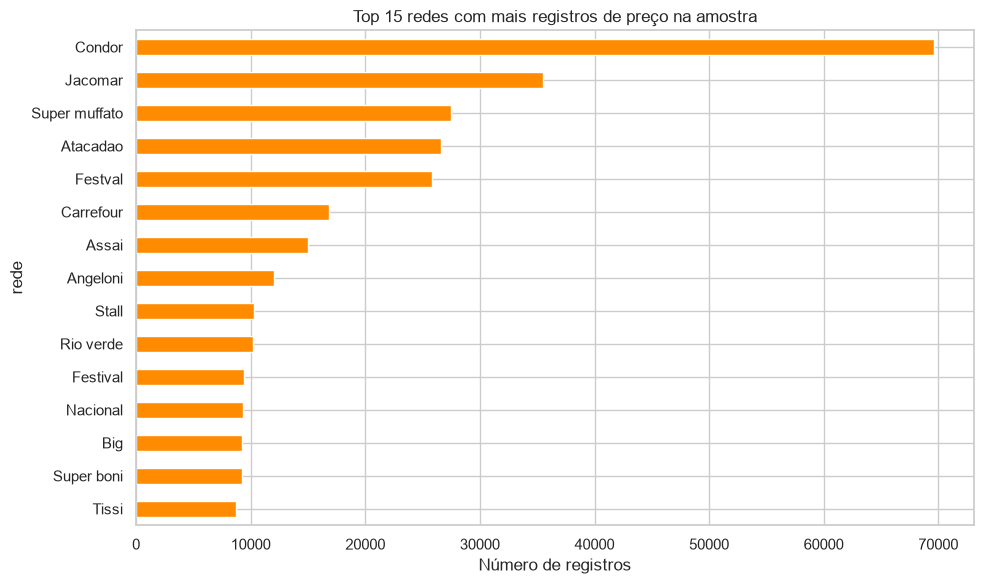

In [33]:
top_redes = df["rede"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_redes.plot(kind="barh", color="darkorange")
plt.title("Top 15 redes com mais registros de preço na amostra")
plt.xlabel("Número de registros")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/top_redes.png", dpi=150)
plt.show()

### 6.3. Correlação entre variáveis de preço

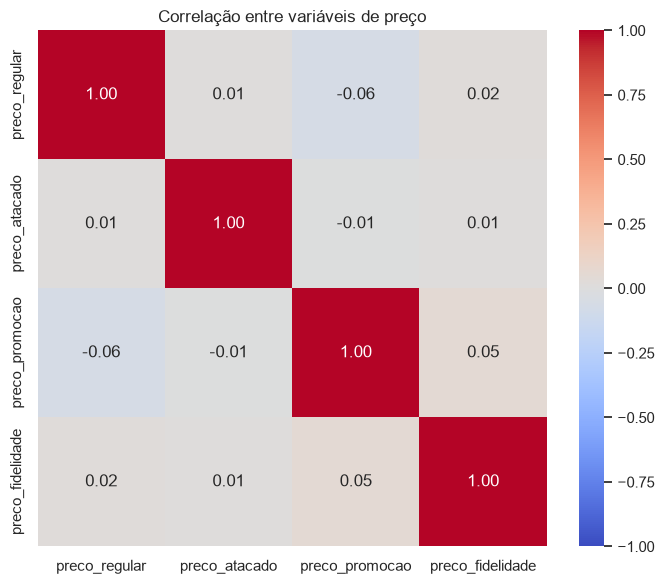

In [34]:
# preco_atacado_qtd fora da correlacao: e zero em todo o dataset (ver secao 2.1), sem variancia para correlacionar
correlation = df[price_columns].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis de preço")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/correlacao_precos.png", dpi=150)
plt.show()

Correlação praticamente nula entre todas as variáveis (-0,06 a 0,05), esperado já que `preco_atacado`, `preco_promocao` e `preco_fidelidade` são majoritariamente zero (condição especial ausente na maior parte dos produtos, ver seção 3.4) e não variam de forma relacionada ao `preco_regular`.

## 7. Cesta básica com produtos padronizados

Comparar itens básicos com busca por palavra-chave e média simples traz três problemas: entram produtos que não são os itens essenciais (massa de arroz, refrigerante "sem açúcar", sardinha em óleo), a média mistura embalagens de 1 kg e de 5 kg, e cada rede vende um mix diferente de produtos.

Esta seção refaz a análise com a prática usada em pesquisas de preço: comparar o mesmo produto, com o preço convertido por unidade de medida. A cesta segue a metodologia do DIEESE, que multiplica o preço de cada item pelas quantidades mensais do Decreto-Lei 399/1938. Como a seleção fica restrita a poucos produtos, a leitura usa o dataset completo, e não a amostra.

### 7.1. Seleção dos produtos

In [35]:
# a descricao precisa comecar pelo nome do item; o lookahead exclui arroz integral
item_rules = {
    "arroz": r"^arroz (?:polido|parboilizado)(?!.*integral)",
    "feijao": r"^feijao (?:carioca|preto|de cor|vermelho)\b",
    "acucar": r"^acucar (?:refinado|cristal)\b",
    # oleo de soja, de canola ou sem tipo informado ("oleo -marca"); outros tipos ficam de fora
    "oleo": r"^oleo(?: de (?:soja|canola)\b|\s*-|\s*\(|$)",
}
read_columns = ["data_pesquisa", "rede", "id_produto", "descricao"] + price_priority

selected_chunks = []
with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000, usecols=read_columns):
            chunk["descricao_norm"] = chunk["descricao"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
            chunk["item"] = None
            for item, rule in item_rules.items():
                chunk.loc[chunk["descricao_norm"].str.contains(rule, regex=True, na=False), "item"] = item
            selected_chunks.append(chunk[chunk["item"].notna()])

df_cesta = pd.concat(selected_chunks, ignore_index=True)
df_cesta["data_pesquisa"] = pd.to_datetime(df_cesta["data_pesquisa"], errors="coerce")
df_cesta["preco_efetivo"] = df_cesta[price_priority].replace(0, np.nan).bfill(axis=1).iloc[:, 0]
# a partir de abril de 2023 todos os produtos trazem tamanho de embalagem (secao 3.7)
df_cesta = df_cesta[(df_cesta["preco_efetivo"] >= 0.30) & (df_cesta["data_pesquisa"] >= "2023-04-01")].reset_index(drop=True)

df_cesta.groupby("item").agg(produtos=("id_produto", "nunique"), registros=("id_produto", "size"))

,produtos,registros
item,,
acucar,23,75472
arroz,46,140513
feijao,23,75808
oleo,6,33086


In [36]:
# conferencia manual das descricoes que entraram em cada item
for item, group in df_cesta.groupby("item"):
    print(f"{item}: {group['descricao_norm'].nunique()} descrições distintas")
    print(group["descricao_norm"].value_counts().head(6).to_string())
    print()

acucar: 27 descrições distintas
descricao_norm
acucar refinado -( + ) barato -1 kg    8333
acucar refinado -( + ) barato -5 kg    7976
acucar cristal -( + ) barato -5 kg     7202
acucar refinado -caravelas -5 kg       6714
acucar refinado -caravelas -1 kg       6291
acucar refinado -alto alegre -1 kg     5884

arroz: 48 descrições distintas
descricao_norm
arroz parboilizado -( + ) barato -1 kg    9340
arroz polido -( + ) barato -1 kg          9110
arroz parboilizado -( + ) barato -5 kg    8221
arroz parboilizado -urbano -1 kg          8201
arroz polido -( + ) barato -5 kg          8119
arroz parboilizado -urbano -5 kg          7888

feijao: 24 descrições distintas
descricao_norm
feijao preto -( + ) barato -1 kg          9551
feijao carioca -( + ) barato -1 kg        8205
feijao carioca -pe vermelho -1 kg         7369
feijao carioca -caldo bom -1 kg           7218
feijao preto -pe vermelho -1 kg           7102
feijao preto -pontarollo premium -1 kg    5411

oleo: 7 descrições distintas


Até 2022, a pesquisa registrava produtos genéricos (ex.: "arroz polido"), sem marca nem tamanho de embalagem, e os códigos de produto foram substituídos em março de 2023. A partir de abril de 2023, todos os registros trazem tamanho (seção 3.7), e por isso esta seção começa nesse mês.

Os produtos são escolhidos por regras ancoradas no início da descrição, o que exclui itens em que a palavra aparece no meio do nome. Entram arroz polido e parboilizado; feijão carioca, preto, de cor e vermelho; açúcar refinado e cristal; e óleo de soja, de canola ou sem tipo informado. Ficam de fora arroz integral e açúcar mascavo e demerara, que não são os tipos de consumo comum.

A partir de abril de 2023, as regras selecionaram 98 produtos e 324.879 registros. A conferência mostra só os tipos esperados de cada item, sem os falsos positivos de uma busca simples por palavra-chave.

### 7.2. Preço por quilo ou litro

In [37]:
size_pattern = r"-\s*(\d+(?:[.,]\d+)?)\s*(kg|g|gr|l|lt|ml)\b"
size = df_cesta["descricao_norm"].str.extract(size_pattern)
amount = size[0].str.replace(",", ".").astype(float)
df_cesta["quantidade"] = np.where(size[1].isin(["g", "gr", "ml"]), amount / 1000, amount)  # em kg ou litro

size_coverage = df_cesta.groupby(df_cesta["data_pesquisa"].dt.year)["quantidade"].apply(lambda s: round(100 * s.notna().mean(), 1))
print("% de registros com tamanho na descrição, por ano:")
print(size_coverage.to_string())
print()
print(f"Registros sem tamanho na descrição (descartados): {df_cesta['quantidade'].isna().sum():,}")
df_cesta = df_cesta.dropna(subset=["quantidade"]).reset_index(drop=True)
df_cesta["preco_unitario"] = df_cesta["preco_efetivo"] / df_cesta["quantidade"]
df_cesta["ano_mes"] = df_cesta["data_pesquisa"].dt.to_period("M")
print(f"Registros com preço por kg ou litro: {len(df_cesta):,}")
print()
print(df_cesta.groupby("item")["quantidade"].value_counts().to_string())

df_cesta.groupby("item")["preco_unitario"].describe().round(2)

% de registros com tamanho na descrição, por ano:
data_pesquisa
2023    100.0
2024    100.0
2025    100.0
2026    100.0

Registros sem tamanho na descrição (descartados): 0
Registros com preço por kg ou litro: 324,879

item    quantidade
acucar  5.0           44925
        1.0           27372
        2.0            3175
arroz   5.0           82566
        1.0           57592
        2.0             355
feijao  1.0           75808
oleo    0.9           33086


,count,mean,std,min,25%,50%,75%,max
item,,,,,,,,
acucar,75472.0,4.01,0.70,2.10,3.58,3.90,4.48,7.99
arroz,140513.0,5.41,1.44,0.98,4.39,5.29,6.40,10.99
feijao,75808.0,6.85,2.24,1.45,5.38,6.49,7.98,23.98
oleo,33086.0,8.63,2.35,4.39,7.43,8.10,8.88,19.09


O tamanho da embalagem é extraído da descrição (ex.: "-5 kg", "-900 ml") e o preço efetivo é dividido por ele. Com o início em abril de 2023, todos os registros selecionados têm tamanho e nenhum precisou ser descartado. O preço por quilo varia bastante entre tipos do mesmo item: o óleo de canola custa cerca de 1,7 vez o de soja por litro, e o feijão vermelho, quase o dobro do preto.

### 7.3. Preço por quilo ao longo do tempo

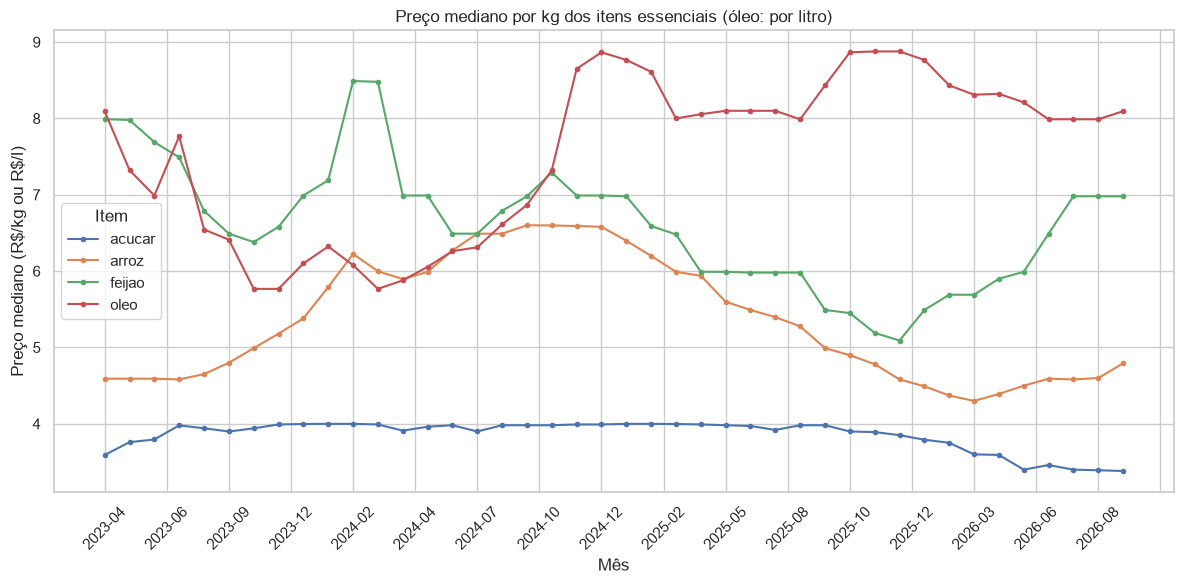

,primeiro_mes,ultimo_mes,maximo,mes_do_maximo
item,,,,
acucar,3.59,3.38,4.00,2024-01
arroz,4.59,4.79,6.60,2024-09
feijao,7.99,6.98,8.49,2024-02
oleo,8.09,8.09,8.88,2025-11


In [38]:
monthly_unit_price = df_cesta.groupby(["ano_mes", "item"])["preco_unitario"].median().unstack("item")

plt.figure(figsize=(12, 6))
for item in monthly_unit_price.columns:
    plt.plot(monthly_unit_price.index.astype(str), monthly_unit_price[item], marker="o", markersize=3, label=item)

plt.title("Preço mediano por kg dos itens essenciais (óleo: por litro)")
plt.xlabel("Mês")
plt.ylabel("Preço mediano (R\\$/kg ou R\\$/l)")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=20))
plt.xticks(rotation=45)
plt.legend(title="Item")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_preco_por_kg_mensal.png", dpi=150)
plt.show()

pd.DataFrame({
    "primeiro_mes": monthly_unit_price.iloc[0],
    "ultimo_mes": monthly_unit_price.iloc[-1],
    "maximo": monthly_unit_price.max(),
    "mes_do_maximo": monthly_unit_price.idxmax().astype(str),
}).round(2)

A série usa a mediana mensal do preço por quilo (por litro, no óleo), menos sensível a valores extremos que a média.

O arroz sobe de 4,59 reais/kg em abril de 2023 para 6,60 em setembro de 2024 e volta a 4,79 em setembro de 2026. O feijão tem máximo de 8,49 reais/kg em fevereiro de 2024, o açúcar fica perto de 4 reais/kg e cai para 3,38, e o óleo chega a 8,88 reais/l em novembro de 2025.

### 7.4. Custo da cesta

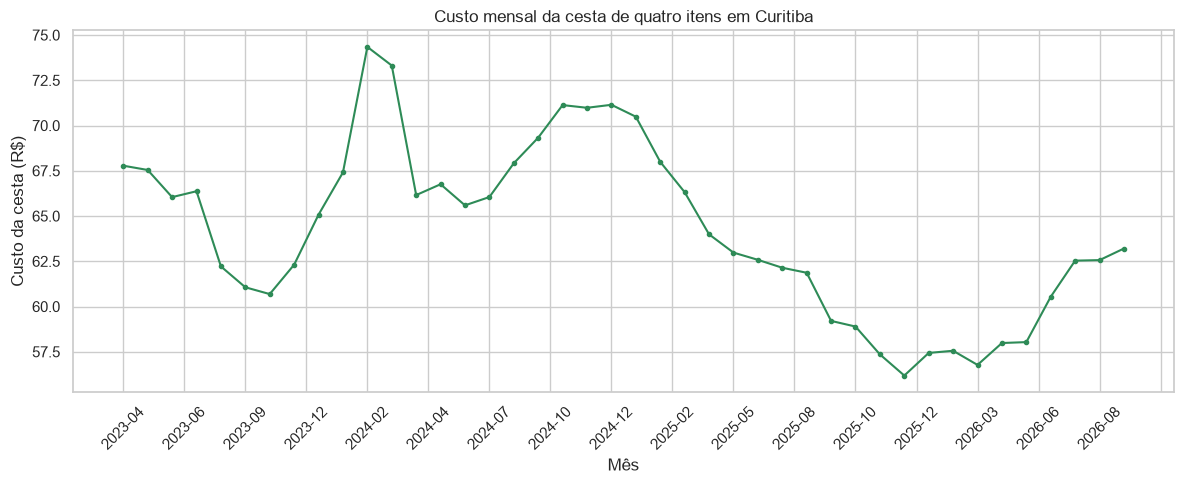

Primeiro mês (2023-04): R$ 67.78
Pico (2024-02): R$ 74.34
Último mês (2026-09): R$ 63.21


In [39]:
cesta_quantities = pd.Series({"arroz": 3.0, "feijao": 4.5, "acucar": 3.0, "oleo": 0.9})

city_cost = (monthly_unit_price * cesta_quantities).sum(axis=1, min_count=len(cesta_quantities))

plt.figure(figsize=(12, 5))
plt.plot(city_cost.index.astype(str), city_cost.values, marker="o", markersize=3, color="seagreen")
plt.title("Custo mensal da cesta de quatro itens em Curitiba")
plt.xlabel("Mês")
plt.ylabel("Custo da cesta (R$)")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_custo_mensal.png", dpi=150)
plt.show()

print(f"Primeiro mês ({city_cost.index[0]}): R$ {city_cost.iloc[0]:.2f}")
print(f"Pico ({city_cost.idxmax()}): R$ {city_cost.max():.2f}")
print(f"Último mês ({city_cost.index[-1]}): R$ {city_cost.iloc[-1]:.2f}")

As quantidades mensais são as do Decreto-Lei 399/1938 para a Região 3, que inclui o Paraná: 3 kg de arroz, 4,5 kg de feijão, 3 kg de açúcar e 900 g de óleo, aproximados aqui por uma embalagem de 900 ml. A cesta tem só os quatro itens deste estudo, e não os 13 da cesta completa do DIEESE, então o valor não é comparável ao divulgado pelo DIEESE.

A cesta de quatro itens custa 67,78 reais em abril de 2023, chega a 74,34 reais em fevereiro de 2024, puxada pelo pico do feijão, e fecha em 63,21 reais em setembro de 2026.

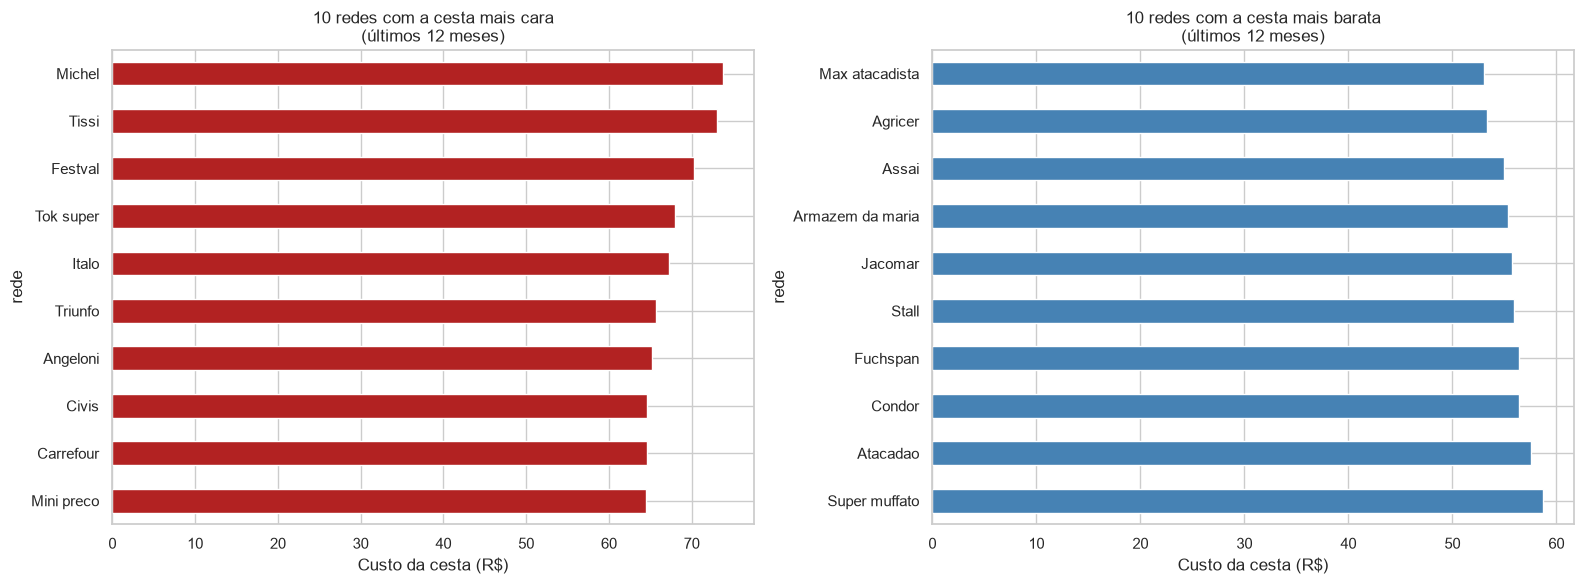

Período: 2025-10 a 2026-09
Redes com os quatro itens: 34
Mais barata: Max atacadista (R$ 53.05)
Mais cara: Michel (R$ 73.83)
Diferença: 39.2%


In [40]:
# comparacao entre redes nos ultimos 12 meses; exige registros dos quatro itens em cada rede
last_month = df_cesta["ano_mes"].max()
df_recent = df_cesta[df_cesta["ano_mes"] > last_month - 12].copy()

records_per_item = df_recent.groupby(["rede", "item"]).size().unstack("item").fillna(0)
eligible_networks = records_per_item[(records_per_item >= 20).all(axis=1)].index

network_unit_price = df_recent[df_recent["rede"].isin(eligible_networks)].groupby(["rede", "item"])["preco_unitario"].median().unstack("item")
network_cost = (network_unit_price * cesta_quantities).sum(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
network_cost.tail(10).sort_values(ascending=False).plot(kind="barh", color="firebrick", ax=axes[0])
axes[0].set_title("10 redes com a cesta mais cara\n(últimos 12 meses)")
axes[0].set_xlabel("Custo da cesta (R$)")
axes[0].invert_yaxis()
network_cost.head(10).plot(kind="barh", color="steelblue", ax=axes[1])
axes[1].set_title("10 redes com a cesta mais barata\n(últimos 12 meses)")
axes[1].set_xlabel("Custo da cesta (R$)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_custo_por_rede.png", dpi=150)
plt.show()

print(f"Período: {df_recent['ano_mes'].min()} a {last_month}")
print(f"Redes com os quatro itens: {len(network_cost)}")
print(f"Mais barata: {network_cost.index[0]} (R$ {network_cost.iloc[0]:.2f})")
print(f"Mais cara: {network_cost.index[-1]} (R$ {network_cost.iloc[-1]:.2f})")
print(f"Diferença: {100 * (network_cost.iloc[-1] / network_cost.iloc[0] - 1):.1f}%")

Entre outubro de 2025 e setembro de 2026, 34 redes têm pelo menos 20 registros de cada item. A cesta vai de 53,05 reais na Max Atacadista a 73,83 reais na Michel, uma diferença de 39,2%.